# Kernel I2bar(t,s) at a fixed external k
Direct mode-function solve (kernel.I2bar_numeric, no fast tabulation machinery), on the QCD background, compared to the exact-RD closed form.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../core'))
import numpy as np
import matplotlib.pyplot as plt
import plotstyle; plotstyle.use_latex()
import kernel as K
import background_qcd as qcd

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta)...
  norm = 0.9836281477


In [2]:
k = 1e3   # external wavenumber [Mpc^-1]
g1m, g2m = K.match_tensor(k, qcd)

t_grid = np.geomspace(1e-2, 30.0, 60)
s_grid = np.linspace(0.0, 1.0 - 1e-9, 40)
I2 = np.zeros((len(t_grid), len(s_grid)))
for i, t in enumerate(t_grid):
    for j, s in enumerate(s_grid):
        I2[i, j] = K.I2bar_numeric(k, t, s, qcd, g1m, g2m)
print('done')

done


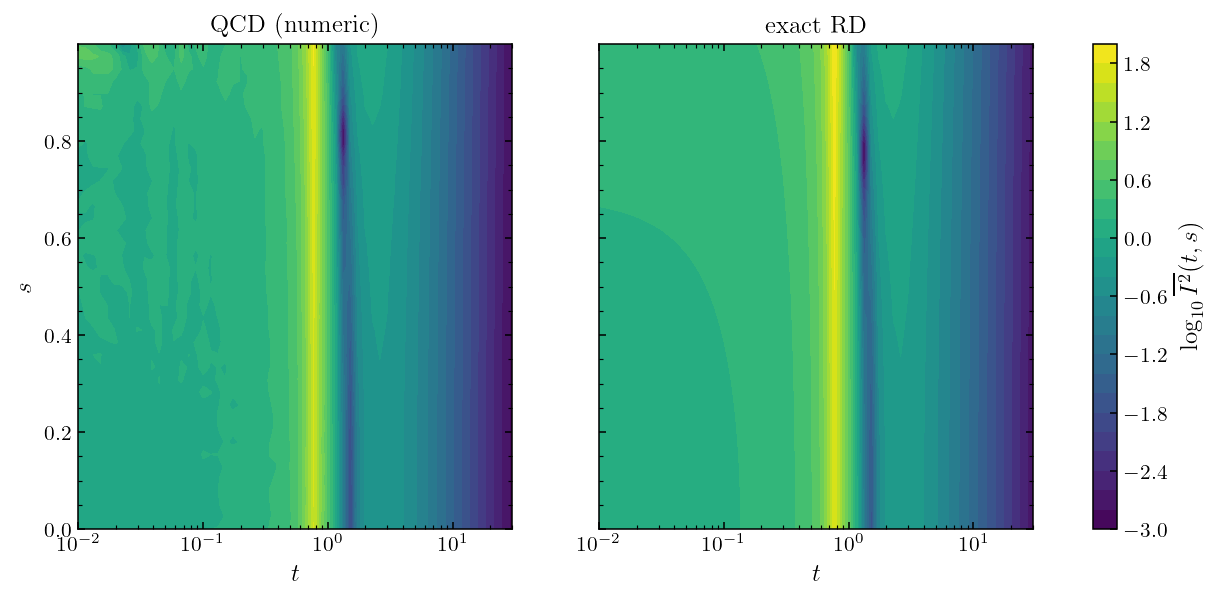

In [3]:
T, S = np.meshgrid(t_grid, s_grid, indexing='ij')
I2_rd = K.I2bar_rd_exact(T, S)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, Z, title in zip(axes, [I2, I2_rd], ['QCD (numeric)', 'exact RD']):
    cs = ax.contourf(T, S, np.log10(np.clip(Z, 1e-3, None)), levels=30)
    ax.set_xscale('log'); ax.set_xlabel('$t$'); ax.set_title(title)
axes[0].set_ylabel('$s$')
fig.colorbar(cs, ax=axes, label=r'$\log_{10}\overline{I^2}(t,s)$')
plt.show()

## Cut at s=0

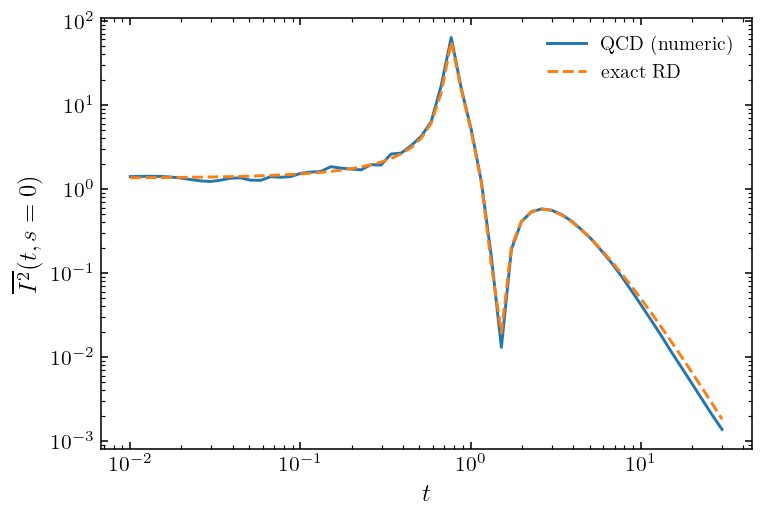

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(t_grid, I2[:, 0], label='QCD (numeric)')
ax.loglog(t_grid, I2_rd[:, 0], label='exact RD', ls='--')
ax.set_xlabel('$t$'); ax.set_ylabel(r'$\overline{I^2}(t,s=0)$'); ax.legend()
plt.show()